In [1]:
import os
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
folder_path=r"Desktop/rice_leaf_diseases_1/Bacterial leaf blight"
width=256
height=80
for filename in os.listdir(folder_path):
    if filename.endswith(('.png','.jpg','.JPG','.jpeg','.gif')):
        image_path=os.path.join(folder_path,filename)
        image=Image.open(image_path)
        resized_image=image.resize((width,height))
        resized_image.save(image_path)
        image.close()

In [3]:
folder_path=r"Desktop/rice_leaf_diseases_1/Brown spot"
width=256
height=80
for filename in os.listdir(folder_path):
    if filename.endswith(('.png','.JPG','.jpg','.jpeg','.gif')):
        image_path=os.path.join(folder_path,filename)
        image=Image.open(image_path)
        resized_image=image.resize((width,height))
        resized_image.save(image_path)
        image.close()

In [4]:
folder_path=r"Desktop/rice_leaf_diseases_1/Leaf smut"
width=256
height=80
for filename in os.listdir(folder_path):
    if filename.endswith(('.png','.jpg','.JPG','.jpeg','.gif')):
        image_path=os.path.join(folder_path,filename)
        image=Image.open(image_path)
        resized_image=image.resize((width,height))
        resized_image.save(image_path)
        image.close()

In [30]:
width=256
height=80
BATCH_SIZE=16
CHANNELS=3
EPOCHS=150

In [3]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    'Desktop/rice_leaf_diseases_1',
    shuffle=True,
    image_size=(height,width),
    batch_size=BATCH_SIZE


)

Found 120 files belonging to 3 classes.


In [4]:
class_names=dataset.class_names
class_names

['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

In [5]:
len(dataset)

8

In [6]:
for image_batch,label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())

(16, 80, 256, 3)
[0 0 1 0 1 1 1 2 0 1 1 2 2 0 0 1]


2024-07-02 18:34:04.822096: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
for image_batch,label_batch in dataset.take(1):
    print(image_batch[0])

tf.Tensor(
[[[239. 228. 224.]
  [239. 228. 224.]
  [239. 228. 224.]
  ...
  [236. 223. 217.]
  [236. 223. 217.]
  [236. 223. 217.]]

 [[239. 228. 224.]
  [239. 228. 224.]
  [239. 228. 224.]
  ...
  [236. 223. 217.]
  [236. 223. 217.]
  [236. 223. 217.]]

 [[239. 228. 224.]
  [239. 228. 224.]
  [239. 228. 224.]
  ...
  [236. 223. 217.]
  [236. 223. 217.]
  [236. 223. 217.]]

 ...

 [[237. 226. 222.]
  [237. 226. 222.]
  [237. 226. 222.]
  ...
  [236. 223. 217.]
  [236. 223. 217.]
  [236. 223. 217.]]

 [[237. 226. 222.]
  [237. 226. 222.]
  [237. 226. 222.]
  ...
  [236. 223. 217.]
  [236. 223. 217.]
  [236. 223. 217.]]

 [[237. 226. 222.]
  [237. 226. 222.]
  [237. 226. 222.]
  ...
  [236. 223. 217.]
  [236. 223. 217.]
  [236. 223. 217.]]], shape=(80, 256, 3), dtype=float32)


2024-07-02 18:34:05.088686: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
for image_batch,label_batch in dataset.take(1):
    print(image_batch[0].numpy())

[[[237. 224. 215.]
  [238. 225. 216.]
  [238. 225. 216.]
  ...
  [238. 225. 216.]
  [238. 225. 216.]
  [237. 224. 215.]]

 [[237. 224. 215.]
  [238. 225. 216.]
  [238. 225. 216.]
  ...
  [238. 225. 216.]
  [238. 225. 216.]
  [237. 224. 215.]]

 [[237. 224. 215.]
  [238. 225. 216.]
  [238. 225. 216.]
  ...
  [238. 225. 216.]
  [238. 225. 216.]
  [237. 224. 215.]]

 ...

 [[237. 228. 213.]
  [237. 228. 213.]
  [237. 228. 213.]
  ...
  [235. 227. 214.]
  [236. 228. 215.]
  [236. 228. 215.]]

 [[237. 226. 208.]
  [237. 226. 208.]
  [235. 227. 208.]
  ...
  [235. 227. 216.]
  [236. 228. 217.]
  [236. 228. 217.]]

 [[239. 228. 208.]
  [239. 228. 208.]
  [238. 230. 209.]
  ...
  [235. 227. 216.]
  [236. 228. 217.]
  [236. 228. 217.]]]


2024-07-02 18:34:05.186697: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2024-07-02 18:34:05.809104: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


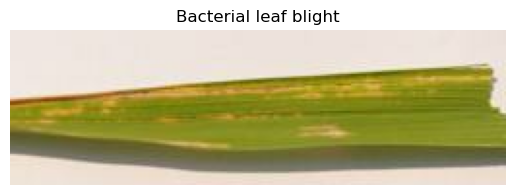

In [9]:
for image_batch,label_batch in dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype('uint8'))
    plt.title(class_names[label_batch[0]])
    plt.axis('off')

2024-07-02 18:34:06.913826: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


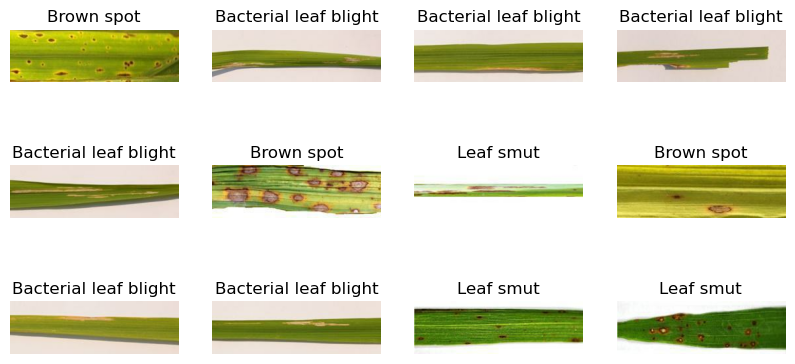

In [10]:
plt.figure(figsize=(10,5))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        
        plt.title(class_names[label_batch[i]])
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.axis('off')

In [11]:
#   80%>>training
#  10%>>validation,10%>> testing

In [12]:
train_ds=tf.keras.utils.image_dataset_from_directory('Desktop/rice_leaf_diseases_1',
                                                    shuffle=True,
                                                     validation_split=0.2,
                                                     subset='training',
                                                     seed=100,
                                                     image_size=(height,width),
                                                     batch_size=16
)

Found 120 files belonging to 3 classes.
Using 96 files for training.


In [13]:
len(train_ds)

6

In [14]:
validation_ds=tf.keras.utils.image_dataset_from_directory('Desktop/rice_leaf_diseases_1',
                                                    shuffle=True,
                                                    validation_split=0.2,
                                                    subset='validation',
                                                    seed=100,
                                                    batch_size=16,
                                                    image_size=(height,width)
)

test_ds=validation_ds.take(1)
validation_ds=validation_ds.skip(1)



Found 120 files belonging to 3 classes.
Using 24 files for validation.


In [15]:
len(validation_ds)

1

In [16]:
len(train_ds)

6

In [17]:

len(test_ds)

1

In [18]:
train_ds=train_ds.cache().shuffle(76).prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds=validation_ds.cache().shuffle(10).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(19).prefetch(buffer_size=tf.data.AUTOTUNE)

In [19]:
resize_and_rescale= tf.keras.Sequential([layers.Resizing(height,width),
                                        layers.Rescaling(1/256)
                                        
                                        ])

In [20]:
data_augumentation=tf.keras.Sequential([layers.RandomFlip('horizontal_and_vertical'),
                                       layers.RandomRotation(0.2),
                                        layers.RandomZoom(0.7),
                                        layers.RandomContrast(0.3)
                                       ])

In [25]:
input_shape=(16,height,width,3)
cnn=keras.Sequential([resize_and_rescale,data_augumentation,
                 keras.layers.Conv2D(filters=34,kernel_size=(3,3),activation='relu',input_shape=input_shape),
                  keras.layers.MaxPooling2D(2,2),
                  keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
                keras.layers.MaxPooling2D(2,2),
                keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
                  keras.layers.MaxPooling2D(2,2),
                  keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
                keras.layers.MaxPooling2D(2,2),
                      
                      
                
                keras.layers.Flatten(),
                    keras.layers.Dense(500),
                keras.layers.Dense(3,activation='softmax') 
                 
                 ])
                                     
cnn.build(input_shape=input_shape)

In [26]:
cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (16, 80, 256, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (16, 80, 256, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (16, 78, 254, 34)      │           952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (16, 39, 127, 34)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (16, 37, 125, 64)      │        19,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (16, 18, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (16, 16, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (16, 8, 30, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (16, 6, 28, 64)        │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (16, 3, 14, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (16, 2688)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (16, 500)              │     1,344,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (16, 3)                │         1,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,440,459 (5.49 MB)

 Trainable params: 1,440,459 (5.49 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [31]:
cnn.fit(train_ds,epochs=EPOCHS,batch_size=BATCH_SIZE,validation_data=validation_ds)

Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 650ms/step - accuracy: 0.6707 - loss: 0.7236 - val_accuracy: 0.8750 - val_loss: 0.8219
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 610ms/step - accuracy: 0.6805 - loss: 0.6802 - val_accuracy: 0.8750 - val_loss: 0.9241
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 618ms/step - accuracy: 0.6814 - loss: 0.6712 - val_accuracy: 0.7500 - val_loss: 0.6615
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 620ms/step - accuracy: 0.6299 - loss: 0.8085 - val_accuracy: 0.8750 - val_loss: 1.0352
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 617ms/step - accuracy: 0.6347 - loss: 0.7731 - val_accuracy: 0.6250 - val_loss: 0.8238
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 614ms/step - accuracy: 0.6778 - loss: 0.8051 - val_accuracy: 0.7500 - val_loss: 0.9862
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 617ms/step - accuracy: 0.6652 - loss: 0.8132 - val_accuracy: 0.7500 - val_loss: 1.1171
Epoch 8/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 611ms/step - accuracy: 0.7249 - loss: 0.6434 - val_accuracy: 0.7500 - v

In [41]:
prediction=cnn.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.8125 - loss: 0.2978


[[[236 223 217]
  [236 223 217]
  [236 223 217]
  ...
  [237 224 216]
  [237 224 216]
  [237 224 216]]

 [[236 223 217]
  [236 223 217]
  [236 223 217]
  ...
  [237 224 216]
  [237 224 216]
  [236 223 215]]

 [[236 223 217]
  [236 223 217]
  [236 223 217]
  ...
  [237 224 216]
  [236 223 215]
  [236 223 215]]

 ...

 [[240 231 222]
  [240 231 222]
  [239 230 221]
  ...
  [238 225 219]
  [238 225 219]
  [238 225 219]]

 [[241 232 223]
  [240 231 222]
  [240 231 222]
  ...
  [238 225 219]
  [238 225 219]
  [238 225 219]]

 [[241 232 223]
  [241 232 223]
  [240 231 222]
  ...
  [238 225 219]
  [238 225 219]
  [238 225 219]]]


2024-07-02 21:25:08.866945: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


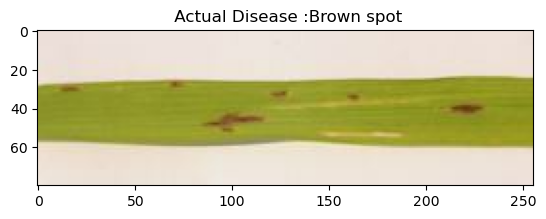

In [47]:
for image_batch,label_image in test_ds.take(1):
    plt.title(f" Actual Disease :{class_names[label_image[0]]},\n Predicted Diease :")
    img=image_batch[0].numpy().astype('uint8')
    plt.imshow(img)
    print(img)

In [1]:
# to 200 epochs and above we can get 0.9 and above accuracy